# Ensaio de Clusterização

Ensaio de Machine Learning para os algoritmos de clusterização: **K-Means** e **Affinity Propagation**, seguindo o mesmo padrão de metodologia usado nos ensaios de classificação e regressão (busca de hiperparâmetro, avaliação via métrica adequada — aqui, o *Average Silhouette Score* — e seleção do melhor modelo).

In [1]:
#bibliotecas
import pandas as pd
import numpy as np
from sklearn import cluster as cl
from sklearn import metrics as mt
from matplotlib import pyplot as plt

In [2]:
#Carregamento dos dados
X = pd.read_csv('dataset3/X_dataset.csv')
X.head()

,alcohol,malic_acid,ash,ash_alcanity,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280,proline
0,1.518613,0.191700,0.232053,-1.169593,1.913905,0.627586,0.573840,-0.659563,1.224884,0.251717,0.455285,0.970696,0.561341
1,0.246290,0.205534,-0.827996,-2.490847,0.018145,0.575862,0.510549,-0.820719,-0.544721,-0.293321,0.463415,0.780220,0.550642
2,0.196879,0.320158,1.109334,-0.268738,0.088358,0.627586,0.611814,-0.498407,2.135968,0.269020,0.447154,0.695971,0.646933
3,1.691550,0.239130,0.487926,-0.809251,0.930918,0.989655,0.664557,-0.981875,1.032155,1.186068,0.308943,0.798535,0.857347
4,0.295700,0.365613,1.840403,0.451946,1.281985,0.627586,0.495781,0.226796,0.401404,-0.319276,0.455285,0.608059,0.325963


## 1. K-Means

In [3]:
#Busca do número de clusters (k) através do Average Silhouette Score
values_k = [i for i in range(2, 21)]
values_silhouette = list()

for i in values_k:
    kmeans = cl.KMeans(n_clusters=i, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)

    sil_score = mt.silhouette_score(X, labels)
    values_silhouette.append(sil_score)

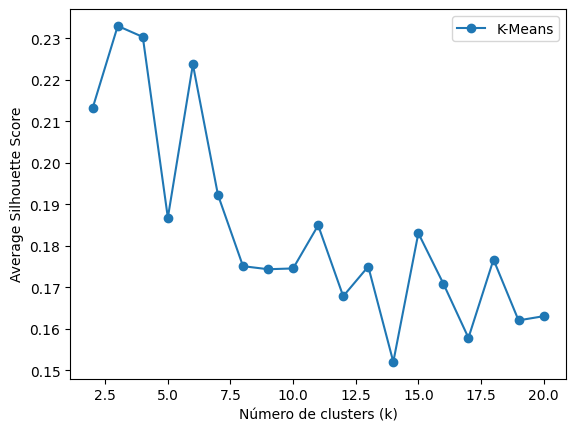

In [4]:
#plot do Average Silhouette Score em função do número de clusters
plt.plot(values_k, values_silhouette, '-o', label='K-Means')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.legend()
plt.show()

In [5]:
#Melhor número de clusters (maior Average Silhouette Score)
best_k = values_k[np.argmax(values_silhouette)]
print(f"Melhor número de clusters: {best_k}")
print(f"Melhor Average Silhouette Score: {max(values_silhouette)}")

Melhor número de clusters: 3
Melhor Average Silhouette Score: 0.23295918228054466


In [6]:
#Modelo final treinado com o melhor k
kmeans = cl.KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X)

sil_kmeans = mt.silhouette_score(X, labels_kmeans)
n_clusters_kmeans = len(np.unique(labels_kmeans))

print(f"Número de clusters: {n_clusters_kmeans}")
print(f"Average Silhouette Score: {sil_kmeans}")

Número de clusters: 3
Average Silhouette Score: 0.23295918228054466


## 2. Affinity Propagation

In [7]:
#Busca do parâmetro damping através do Average Silhouette Score
values_damping = [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
values_silhouette_ap = list()
values_n_clusters_ap = list()

for d in values_damping:
    ap = cl.AffinityPropagation(damping=d, random_state=42)
    labels = ap.fit_predict(X)

    sil_score = mt.silhouette_score(X, labels)
    values_silhouette_ap.append(sil_score)
    values_n_clusters_ap.append(len(np.unique(labels)))

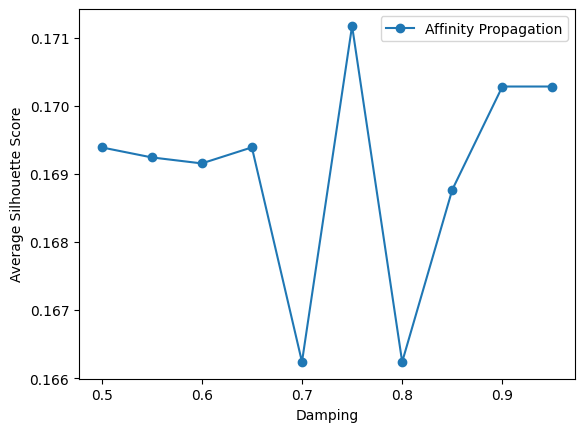

In [8]:
#plot do Average Silhouette Score em função do damping
plt.plot(values_damping, values_silhouette_ap, '-o', label='Affinity Propagation')
plt.xlabel('Damping')
plt.ylabel('Average Silhouette Score')
plt.legend()
plt.show()

In [9]:
#Melhor damping (maior Average Silhouette Score)
best_damping = values_damping[np.argmax(values_silhouette_ap)]
print(f"Melhor damping: {best_damping}")
print(f"Melhor Average Silhouette Score: {max(values_silhouette_ap)}")

Melhor damping: 0.75
Melhor Average Silhouette Score: 0.17117070220380765


In [10]:
#Modelo final treinado com o melhor damping
ap = cl.AffinityPropagation(damping=best_damping, random_state=42)
labels_ap = ap.fit_predict(X)

sil_ap = mt.silhouette_score(X, labels_ap)
n_clusters_ap = len(np.unique(labels_ap))

print(f"Número de clusters: {n_clusters_ap}")
print(f"Average Silhouette Score: {sil_ap}")

Número de clusters: 18
Average Silhouette Score: 0.17117070220380765


## Tabela resumo - todos os algoritmos

In [11]:
#Tabela resumo consolidada

resumo_clusterizacao = pd.DataFrame({
    'Algoritmo': ['K-Means', 'Affinity Propagation'],
    'Número de clusters': [n_clusters_kmeans, n_clusters_ap],
    'Average Silhouette Score': [sil_kmeans, sil_ap]
})
resumo_clusterizacao

,Algoritmo,Número de clusters,Average Silhouette Score
0,K-Means,3,0.232959
1,Affinity Propagation,18,0.171171
